In [114]:
import pandas as pd
import matplotlib.pyplot as plt

In [115]:
df = pd.read_csv(
    "../dados/datatran2025.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)


In [116]:
df.shape

(72529, 30)

Então confirmamos que a nossa base tem 72.529 registros e 30 colunas. ✅

In [117]:
df.columns

Index(['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km',
       'municipio', 'causa_acidente', 'tipo_acidente',
       'classificacao_acidente', 'fase_dia', 'sentido_via',
       'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo',
       'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos',
       'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional',
       'delegacia', 'uop'],
      dtype='str')

Tem uma observação importante: o resultado aparece como dtype='object' no final, mas isso não significa que todas as colunas sejam do tipo object. Esse dtype é o tipo do objeto que contém os nomes das colunas. Vamos verificar os tipos reais agora.

In [118]:
df.dtypes

id                        int64
data_inversa                str
dia_semana                  str
horario                     str
uf                          str
br                        int64
km                          str
municipio                   str
causa_acidente              str
tipo_acidente               str
classificacao_acidente      str
fase_dia                    str
sentido_via                 str
condicao_metereologica      str
tipo_pista                  str
tracado_via                 str
uso_solo                    str
pessoas                   int64
mortos                    int64
feridos_leves             int64
feridos_graves            int64
ilesos                    int64
ignorados                 int64
feridos                   int64
veiculos                  int64
latitude                    str
longitude                   str
regional                    str
delegacia                   str
uop                         str
dtype: object

O object não significa necessariamente que está errado.

Significa que o Pandas carregou aquela coluna como texto. Algumas provavelmente são realmente texto, como:

uf
municipio
causa_acidente
tipo_acidente

Mas outras merecem nossa atenção:

data_inversa → provavelmente vamos transformar em data
horario → podemos tratar como horário
km → é uma informação numérica, mas veio como object

👉 Isso já é um problema de qualidade/tipo de dado que podemos documentar no projeto.

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      72529 non-null  int64
 1   data_inversa            72529 non-null  str  
 2   dia_semana              72529 non-null  str  
 3   horario                 72529 non-null  str  
 4   uf                      72529 non-null  str  
 5   br                      72529 non-null  int64
 6   km                      72529 non-null  str  
 7   municipio               72529 non-null  str  
 8   causa_acidente          72529 non-null  str  
 9   tipo_acidente           72529 non-null  str  
 10  classificacao_acidente  72528 non-null  str  
 11  fase_dia                72529 non-null  str  
 12  sentido_via             72529 non-null  str  
 13  condicao_metereologica  72529 non-null  str  
 14  tipo_pista              72529 non-null  str  
 15  tracado_via             72529 

🔎 O que estamos vendo

A base tem:

72.529 registros
30 colunas
O índice vai de 0 até 72528
Quase todas as colunas mostradas estão com 72.529 valores não nulos

Mas olha esta linha:

classificacao_acidente    72528 non-null

A base tem 72.529 linhas, mas essa coluna tem 72.528 valores preenchidos.

👉 Portanto, já encontramos pelo menos 1 valor ausente nessa coluna.

Isso é exatamente o tipo de coisa que precisamos descobrir na etapa de diagnóstico.

⚠️ E tem outro detalhe interessante

Também confirmamos algo que já tínhamos percebido:

km       object

O km provavelmente deveria ser tratado como número, mas foi carregado como texto.

In [120]:
df.isnull().sum()

id                         0
data_inversa               0
dia_semana                 0
horario                    0
uf                         0
br                         0
km                         0
municipio                  0
causa_acidente             0
tipo_acidente              0
classificacao_acidente     1
fase_dia                   0
sentido_via                0
condicao_metereologica     0
tipo_pista                 0
tracado_via                0
uso_solo                   0
pessoas                    0
mortos                     0
feridos_leves              0
feridos_graves             0
ilesos                     0
ignorados                  0
feridos                    0
veiculos                   0
latitude                   0
longitude                  0
regional                   2
delegacia                 22
uop                       38
dtype: int64

🔎 Valores ausentes

O resultado mostra que praticamente todas as colunas estão com 0 valores ausentes.

A exceção que já tínhamos encontrado aparece aqui:

classificacao_acidente    1

Ou seja:

classificacao_acidente possui exatamente 1 valor ausente em 72.529 registros.

In [121]:
df[df["classificacao_acidente"].isnull()]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,...,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE


Essa é exatamente a linha que possui o único valor ausente em classificacao_acidente.
Como só existe 1 valor ausente em 72.529 registros, isso representa uma quantidade praticamente irrelevante da base. Mas, para o projeto, precisamos registrar e justificar a decisão.

Antes de decidir, vamos verificar se existe alguma relação entre classificacao_acidente e outras informações desse registro que possa nos ajudar.

In [122]:
df[df["id"] == 652519].T

,1
id,652519
data_inversa,2025-01-01
dia_semana,quarta-feira
horario,07:50:00
uf,CE
br,116
km,"546,2"
municipio,PENAFORTE
causa_acidente,Pista esburacada
tipo_acidente,Colisão frontal


Agora temos uma informação importante: esse acidente teve 1 morto, então a classificação, pela lógica da própria variável, seria “Com Vítimas Fatais”. A documentação da PRF define essa coluna como uma classificação de gravidade, incluindo “Sem Vítimas”, “Com Vítimas Feridas”, “Com Vítimas Fatais” e “Ignorado”.
O dado original está ausente → isso precisa ser registrado.
Podemos inferir o valor a partir de mortos = 1 → isso pode ser uma decisão de tratamento, mas precisamos justificá-la.

In [123]:
pd.crosstab(df["classificacao_acidente"], df["mortos"])

mortos,0,1,2,3,4,5,6,7,9,10,11,16
classificacao_acidente,,,,,,,,,,,,
Com Vítimas Fatais,0,4631,434,93,28,13,3,2,2,1,1,1
Com Vítimas Feridas,56181,0,0,0,0,0,0,0,0,0,0,0
Sem Vítimas,11138,0,0,0,0,0,0,0,0,0,0,0


A tabela mostra uma relação perfeitamente consistente:
mortos = 0 → acidentes classificados como Com Vítimas Feridas ou Sem Vítimas
mortos > 0 → acidentes classificados como Com Vítimas Fatais
Não encontramos, nessa tabela, nenhum caso de acidente com mortos sendo classificado como outra coisa.

Então, para o nosso registro ID 652519, que possui mortos = 1, podemos justificar o preenchimento como "Com Vítimas Fatais".

### Tratamento do valor ausente em `classificacao_acidente`

Foi identificado apenas um registro com valor ausente na coluna `classificacao_acidente`, correspondente ao acidente de ID 652519.

Ao analisar o registro, verificou-se que o acidente possui 1 vítima fatal (`mortos = 1`). Além disso, a análise da relação entre `classificacao_acidente` e `mortos` mostrou que os registros classificados como "Com Vítimas Fatais" possuem pelo menos uma vítima fatal.

Dessa forma, o valor ausente foi preenchido como "Com Vítimas Fatais", utilizando como critério a informação disponível na própria base.

In [124]:
df.duplicated().sum()


np.int64(0)

72.529 registros analisados e nenhuma duplicidade exata encontrada.

In [125]:
df["id"].duplicated().sum()

np.int64(0)

Significa que não há nenhum ID repetido.

Então, até agora nosso diagnóstico de duplicidades ficou:

Linhas totalmente duplicadas: 0
IDs duplicados: 0

In [126]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

uop                       0.052393
delegacia                 0.030333
regional                  0.002758
classificacao_acidente    0.001379
uso_solo                  0.000000
longitude                 0.000000
latitude                  0.000000
veiculos                  0.000000
feridos                   0.000000
ignorados                 0.000000
ilesos                    0.000000
feridos_graves            0.000000
feridos_leves             0.000000
mortos                    0.000000
pessoas                   0.000000
id                        0.000000
data_inversa              0.000000
tipo_pista                0.000000
condicao_metereologica    0.000000
sentido_via               0.000000
fase_dia                  0.000000
tipo_acidente             0.000000
causa_acidente            0.000000
municipio                 0.000000
km                        0.000000
br                        0.000000
uf                        0.000000
horario                   0.000000
dia_semana          


O que esse resultado mostra

As quatro colunas que apresentam ausência são:
| Coluna                   | Percentual ausente |
| ------------------------ | -----------------: |
| `uop`                    |            0,0524% |
| `delegacia`              |            0,0303% |
| `regional`               |            0,0028% |
| `classificacao_acidente` |            0,0014% |
As demais colunas apresentam 0% de valores ausentes.

Isso é interessante porque mostra que os dados estão muito completos. Mesmo a coluna com maior percentual de ausência (uop) tem apenas cerca de 0,05% dos registros sem informação.

In [127]:
df["uf"].value_counts()

uf
MG    9570
SC    8186
PR    7630
RJ    6428
RS    4899
SP    4683
BA    4108
GO    3196
PE    3013
ES    2642
MT    2636
PB    1978
MS    1654
RN    1648
PI    1490
RO    1452
CE    1302
MA    1262
PA    1117
DF    1011
TO     677
AL     629
SE     589
AC     280
AP     169
RR     142
AM     138
Name: count, dtype: int64

Esse resultado nos dá duas informações importantes. 👀

1. Não aparecem categorias estranhas em uf

Temos as 27 UFs brasileiras, todas representadas pelas siglas padrão:

MG: 9.570
SC: 8.186
PR: 7.630
RJ: 6.428
RS: 4.899
SP: 4.683
...
AM: 138

Então, não identificamos inconsistência aparente nas categorias de uf. Não há, por exemplo, "Santa Catarina" misturado com "SC".

In [128]:
df["tipo_acidente"].value_counts()

tipo_acidente
Colisão traseira                  14360
Saída de leito carroçável         10209
Colisão transversal                9306
Colisão lateral mesmo sentido      7885
Tombamento                         6351
Colisão com objeto                 5109
Colisão frontal                    4739
Queda de ocupante de veículo       3450
Atropelamento de Pedestre          3057
Colisão lateral sentido oposto     2152
Incêndio                           1771
Capotamento                        1373
Engavetamento                      1233
Atropelamento de Animal            1133
Eventos atípicos                    287
Derramamento de carga               107
Sinistro pessoal de trânsito          7
Name: count, dtype: int64

Foram encontradas 17 categorias.
Aqui não aparece nenhuma categoria obviamente inconsistente, como valores vazios, N/A, "não informado" ou categorias duplicadas por diferença de escrita.

In [129]:
df["causa_acidente"].value_counts()

causa_acidente
Ausência de reação do condutor                               11469
Reação tardia ou ineficiente do condutor                     10799
Acessar a via sem observar a presença dos outros veículos     7097
Condutor deixou de manter distância do veículo da frente      4413
Velocidade Incompatível                                       4088
                                                             ...  
Faróis desregulados                                              9
Semáforo com defeito                                             8
Redutor de velocidade em desacordo                               8
Sistema de drenagem ineficiente                                  2
Sinalização encoberta                                            2
Name: count, Length: 69, dtype: int64

O que vale investigar é se existem:

categorias muito parecidas que poderiam representar a mesma situação;
diferenças de maiúsculas/minúsculas;
espaços extras;
valores como "Não informado", "Ignorado" etc.;
categorias que possam dificultar uma análise posterior.

In [130]:
df["km"].head(20)

0       225
1     546,2
2      88,2
3        74
4       471
5       669
6       376
7     207,4
8     708,5
9       7,4
10      327
11      530
12     51,8
13    708,5
14    117,8
15      125
16    105,6
17     1102
18    137,7
19    627,5
Name: km, dtype: str

Agora encontramos um problema de qualidade de dados bem claro. 🔎

A coluna km está como: object

Por que isso acontece?

O problema provavelmente está no separador decimal.

Na base brasileira, os valores decimais aparecem com vírgula:

O Pandas, porém, normalmente espera ponto para reconhecer um número decimal:

Por isso ele acabou tratando km como texto (object) em vez de número.

### Problema identificado:
 a coluna km, apesar de representar uma medida numérica, foi carregada como tipo object, pois apresenta valores decimais utilizando vírgula como separador decimal. Essa característica deverá ser tratada na etapa de limpeza.

In [131]:
df["km"].unique()[:30]

<ArrowStringArray>
[  '225', '546,2',  '88,2',    '74',   '471',   '669',   '376', '207,4',
 '708,5',   '7,4',   '327',   '530',  '51,8', '117,8',   '125', '105,6',
  '1102', '137,7', '627,5',   '826',    '16',   '104',  '73,2',  '46,5',
   '331',   '292',   '124',   '316',   '257', '347,8']
Length: 30, dtype: str

In [132]:
df["km"].value_counts().tail(20)

km
944,9    1
400,1    1
796,8    1
1107     1
664,4    1
571,9    1
499,7    1
326,1    1
743,5    1
850,1    1
578,6    1
691,4    1
642,6    1
645,6    1
32,4     1
404,7    1
475,4    1
287,1    1
1004     1
873,7    1
Name: count, dtype: int64

In [133]:
df["km"].str.replace(",", ".", regex=False).astype(float).lt(0).sum()

np.int64(0)

Por enquanto, nosso diagnóstico da coluna km fica:

km está armazenada como texto (object), embora represente uma variável numérica. A coluna utiliza vírgula como separador decimal em alguns registros, por exemplo 546,2 e 940,7. Será necessário avaliar a conversão para formato numérico na etapa de limpeza.

In [134]:
(df[["pessoas", "mortos", "feridos_leves", "feridos_graves",
     "ilesos", "ignorados", "feridos", "veiculos"]] < 0).sum()

pessoas           0
mortos            0
feridos_leves     0
feridos_graves    0
ilesos            0
ignorados         0
feridos           0
veiculos          0
dtype: int64

In [135]:
(
    df["pessoas"]
    != df["mortos"]
    + df["feridos_leves"]
    + df["feridos_graves"]
    + df["ilesos"]
    + df["ignorados"]
).sum()

np.int64(3823)

Esse resultado é bem importante para o diagnóstico. 🔎

pessoas ≠ mortos + feridos_leves + feridos_graves + ilesos + ignorados

Isso não significa automaticamente que os dados estão errados. Pode haver uma particularidade na forma como a PRF contabiliza essas categorias. Mas é uma inconsistência que merece ser investigada e registrada para a etapa de limpeza.

In [136]:
df.loc[
    df["pessoas"] != (
        df["mortos"]
        + df["feridos_leves"]
        + df["feridos_graves"]
        + df["ilesos"]
        + df["ignorados"]
    ),
    ["id", "pessoas", "mortos", "feridos_leves", "feridos_graves", "ilesos", "ignorados", "feridos"]
].head(10)

,id,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos
1,652519,6,1,1,0,1,4,1
5,652569,4,2,0,0,1,2,0
22,652760,5,0,1,0,3,2,1
30,652812,4,0,0,2,1,2,2
33,652829,2,0,0,0,1,2,0
34,652830,2,0,0,0,1,2,0
42,652869,4,0,0,1,2,4,1
43,652873,8,5,0,0,2,3,0
45,652885,3,0,1,0,1,2,1
48,652918,3,0,0,1,1,2,1


Agora ficou bem mais claro. 👍 E tem uma descoberta importante aqui.

Veja o primeiro registro:

pessoas = 6
mortos = 1
feridos_leves = 1
feridos_graves = 0
ilesos = 1
ignorados = 4

Somando as categorias:

1 + 1 + 0 + 1 + 4 = 7 pessoas

Mas a coluna pessoas informa 6.

Isso acontece em vários dos exemplos. Portanto, realmente existem inconsistências entre essas colunas.

Porém, perceba uma coisa interessante: feridos também não deve simplesmente ser somado às demais categorias, porque ele é um total derivado dos feridos leves + feridos graves. Então não devemos incluí-lo nessa soma.

### Foram identificados 3.823 registros em que o total de pessoas não corresponde à soma das categorias de condição das pessoas (mortos, feridos leves, feridos graves, ilesos e ignorados). 
A inconsistência deverá ser avaliada na etapa de limpeza.

In [137]:
df["diferenca_pessoas"] = (
    df["pessoas"]
    - (
        df["mortos"]
        + df["feridos_leves"]
        + df["feridos_graves"]
        + df["ilesos"]
        + df["ignorados"]
    )
)

df.loc[df["diferenca_pessoas"] != 0, "diferenca_pessoas"].value_counts().sort_index()

diferenca_pessoas
-80       1
-14       1
-13       1
-11      11
-10       5
-9        1
-8        9
-7       11
-6       14
-5       61
-4       85
-3      206
-2     1083
-1     2334
Name: count, dtype: int64

A diferença é sempre negativa, ou seja, nesses registros a soma das categorias de pessoas é maior que o valor informado em pessoas.

📊 O que isso nos mostra?

Dos 3.823 registros inconsistentes:

2.334 têm diferença de apenas 1 pessoa.
1.083 têm diferença de 2 pessoas.
Os demais apresentam diferenças maiores.
Existe 1 registro com diferença de -80, um caso extremamente discrepante.

Portanto, não parece ser simplesmente um pequeno erro isolado.

E tem uma pista interessante: lembra daquele acidente com 82 veículos e apenas 2 pessoas? Pois aqui aparece uma diferença de -80. 👀

Isso provavelmente está relacionado ao mesmo registro.

Essa coluna diferenca_pessoas foi criada apenas para investigação.

In [138]:
df.loc[df["diferenca_pessoas"] == -80, [
    "id",
    "tipo_acidente",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "ilesos",
    "ignorados",
    "veiculos"
]]

,id,tipo_acidente,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,veiculos
10260,707992,Incêndio,2,0,0,0,1,81,82


🎯 Agora encontramos a origem daquela diferença de -80.

O registro é o mesmo que já tínhamos identificado como extremo:

| Campo            |    Valor |
| ---------------- | -------: |
| `id`             |   707992 |
| `tipo_acidente`  | Incêndio |
| `pessoas`        |        2 |
| `mortos`         |        0 |
| `feridos_leves`  |        0 |
| `feridos_graves` |        0 |
| `ilesos`         |        1 |
| `ignorados`      |       81 |
| `veiculos`       |       82 |

A soma das categorias de pessoas é:

0 + 0 + 0 + 1 + 81 = 82

Mas a coluna pessoas informa 2.

Então:

2 - 82 = -80

🔎 O que isso revela?

Temos um registro em que existe uma inconsistência muito grande entre pessoas e as categorias de pessoas.

E é interessante porque o mesmo acidente também possui o maior número de veículos da base, 82.

Isso sugere que pode haver alguma particularidade na forma como esse registro foi preenchido ou contabilizado. Não devemos concluir que é erro sem investigar a regra da fonte.

In [139]:
(
    df.loc[df["diferenca_pessoas"] != 0, "ignorados"] > 0
).sum()

np.int64(3823)

🎯 O resultado foi 3.823, exatamente o total de registros inconsistentes.

Isso revela uma pista muito forte:

Todos os 3.823 registros em que pessoas não corresponde à soma das categorias possuem pelo menos uma pessoa na categoria ignorados.

Isso pode explicar as diferenças, porque ignorados representa pessoas cuja situação não foi informada. Portanto, não podemos simplesmente considerar esses 3.823 registros como erros. Precisamos entender a regra da base antes de qualquer correção.

📌 Diagnóstico até aqui
Foram identificados 3.823 registros em que o número de pessoas não corresponde à soma de mortos, feridos_leves, feridos_graves, ilesos e ignorados. Em todos esses registros há pelo menos uma pessoa classificada como ignorados. O maior desvio encontrado foi de 80 pessoas, em um registro com 82 veículos. Dessa forma, os casos devem ser investigados antes de qualquer tratamento.

In [140]:
df["ignorados"].describe()

count    72529.000000
mean         0.394739
std          0.860584
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         81.000000
Name: ignorados, dtype: float64

👍 Esse resultado fecha bem essa investigação.

👥 Coluna ignorados

Temos:

Mínimo: 0
Mediana: 0
75% dos acidentes: têm até 1 pessoa ignorada
Média: 0,39
Máximo: 81 pessoas ignoradas

E aquele registro extremo que encontramos tem justamente 81 ignorados.

📌 Conclusão do diagnóstico

Temos uma relação clara:

Os 3.823 registros em que pessoas não corresponde à soma das categorias apresentam pessoas classificadas como ignorados. A maior diferença ocorre no registro 707992, que possui 81 pessoas ignoradas, 82 veículos e apenas 2 pessoas registradas na coluna pessoas.

Isso é um achado de qualidade de dados, não necessariamente um erro. A pessoa 2 deverá investigar a regra de preenchimento da base antes de decidir qualquer tratamento.


In [141]:
(df["feridos"] != df["feridos_leves"] + df["feridos_graves"]).sum()

np.int64(0)

| Verificação                                | Resultado                 |
| ------------------------------------------ | ------------------------- |
| Valores negativos nas variáveis de vítimas | **Nenhum**                |
| `feridos` ≠ leves + graves                 | **Nenhum**                |
| `pessoas` ≠ soma das categorias            | **3.823 registros**       |
| Duplicidade de linhas                      | **Nenhuma**               |
| Duplicidade de `id`                        | **Nenhuma**               |
| `km` como variável numérica                | **Está como `object`**    |
| Valores negativos em `km`                  | **Nenhum**                |
| Valores ausentes                           | **63 registros no total** |


In [142]:
(df["pessoas"] == 0).sum(), (df["veiculos"] == 0).sum()

(np.int64(0), np.int64(0))

O resultado significa:
0 acidentes com pessoas = 0
0 acidentes com veiculos = 0

Isso é coerente com a natureza da base, porque cada registro representa uma ocorrência de acidente.

Até agora, não encontramos valores obviamente impossíveis nas contagens de pessoas e veículos. A principal inconsistência numérica encontrada continua sendo aquela dos 3.823 registros em que pessoas não bate com a soma das categorias.

In [143]:
df["data_inversa"].min(), df["data_inversa"].max()

('2025-01-01', '2025-12-31')

O resultado mostra:

Data inicial: 01/01/2025
Data final: 31/12/2025

Então a base está corretamente limitada ao ano de 2025. Não encontramos, nesse teste, registros fora do período esperado.

In [144]:
pd.to_datetime(df["data_inversa"], errors="coerce").isna().sum()

np.int64(0)

No diagnóstico das datas, estamos tranquilos:

período: 01/01/2025 a 31/12/2025
datas inválidas: 0
registros fora de 2025: não identificados

In [145]:
df["horario"].unique()[:30]

<ArrowStringArray>
['06:20:00', '07:50:00', '08:45:00', '11:00:00', '09:30:00', '10:40:00',
 '12:23:00', '17:45:00', '18:40:00', '17:00:00', '20:20:00', '20:00:00',
 '21:00:00', '05:45:00', '19:00:00', '07:20:00', '07:15:00', '06:42:00',
 '06:30:00', '08:20:00', '08:19:00', '11:57:00', '13:30:00', '13:20:00',
 '13:01:00', '14:30:00', '11:30:00', '06:50:00', '14:00:00', '19:20:00']
Length: 30, dtype: str

In [146]:
pd.to_datetime(df["horario"], format="%H:%M:%S", errors="coerce").isna().sum()

np.int64(0)

Os primeiros 30 valores mostram um padrão consistente:

formato HH:MM:SS
exemplos: 06:20:00, 12:23:00, 21:00:00
não apareceu nenhum formato estranho nessa amostra.

Todos os 72.529 horários estão em um formato válido HH:MM:SS.

### A coluna horario apresenta formato consistente e não foram identificados horários inválidos.

In [147]:
df["dia_semana"].value_counts()

dia_semana
sábado           11554
domingo          11470
sexta-feira      11197
segunda-feira    10285
quarta-feira      9556
quinta-feira      9405
terça-feira       9062
Name: count, dtype: int64

A coluna dia_semana apresenta exatamente os 7 dias da semana, sem categorias estranhas ou variações de escrita.

Não encontramos valores ausentes nem categorias inconsistentes nessa coluna.

📌 Diagnóstico: dia_semana apresenta categorias consistentes e completas.

In [148]:
df["fase_dia"].value_counts()

fase_dia
Pleno dia      40375
Plena Noite    24781
Anoitecer       3926
Amanhecer       3447
Name: count, dtype: int64

A coluna fase_dia também está bem consistente. Encontramos apenas quatro categorias.

Não apareceu categoria estranha, vazia ou com grafia aparentemente inconsistente.

📌 Diagnóstico: a variável fase_dia apresenta categorias bem definidas e não possui valores ausentes.

In [149]:
df["condicao_metereologica"].value_counts()

condicao_metereologica
Céu Claro           46375
Nublado             11435
Chuva                6438
Sol                  4201
Garoa/Chuvisco       2422
Ignorado             1000
Nevoeiro/Neblina      553
Vento                 104
Neve                    1
Name: count, dtype: int64

O ponto que chama atenção é Neve com apenas 1 ocorrência. ❄️

Isso não significa que seja um erro. É perfeitamente possível existir um registro de acidente com neve, então não devemos eliminar ou alterar simplesmente por ser raro.

Também temos Ignorado, que é uma categoria válida da própria base, mas representa informação não determinada.

📌 Diagnóstico: a variável condicao_metereologica possui 9 categorias. Não foram identificadas categorias claramente duplicadas ou inconsistentes, porém há categorias de baixa frequência, como Neve (1 registro) e Vento (104 registros), que deverão ser consideradas na análise. A categoria Ignorado possui 1.000 registros.

In [150]:
df["tipo_pista"].value_counts()

tipo_pista
Simples     34733
Dupla       30782
Múltipla     7014
Name: count, dtype: int64

A coluna tipo_pista também está bem consistente. Encontramos apenas três categorias.

Não aparecem valores ausentes nem categorias evidentemente inconsistentes.

📌 Diagnóstico: tipo_pista apresenta categorias padronizadas e sem valores ausentes.

In [151]:
df["tracado_via"].value_counts()

tracado_via
Reta                                           40298
Curva                                           8055
Reta;Declive                                    2059
Reta;Aclive                                     1963
Interseção de Vias                              1735
                                               ...  
Rotatória;Interseção de Vias;Declive;Curva         1
Retorno Regulamentado;Rotatória;Curva              1
Ponte;Viaduto                                      1
Desvio Temporário;Interseção de Vias;Curva         1
Retorno Regulamentado;Rotatória;Aclive;Reta        1
Name: count, Length: 605, dtype: int64

A coluna tracado_via tem 605 categorias diferentes. Isso é bastante, principalmente porque muitas categorias são combinações de características da via.

E existem combinações muito específicas que aparecem apenas 1 vez, como:

Viaduto;Interseção de Vias;Reta

📌 Diagnóstico: a variável tracado_via apresenta 605 categorias distintas, incluindo diversas combinações de características da via. Algumas categorias possuem frequência muito baixa, inclusive registros únicos. Não foram consideradas erros nesta etapa, mas a alta cardinalidade deverá ser avaliada durante a análise e limpeza.

In [152]:
df["sentido_via"].value_counts()

sentido_via
Crescente        38715
Decrescente      33647
Não Informado      167
Name: count, dtype: int64

A coluna sentido_via está bastante consistente.

Não há valores ausentes, e as categorias fazem sentido para a variável.

O único ponto a registrar é Não Informado, com 167 registros. Isso não é necessariamente erro, pois pode ser uma informação que não estava disponível no momento do registro.

📌 Diagnóstico: sentido_via possui três categorias, sem valores ausentes. A categoria Não Informado representa 167 registros e deverá ser considerada na etapa de análise/tratamento.

In [153]:
df["uso_solo"].value_counts()

uso_solo
Não    41444
Sim    31085
Name: count, dtype: int64

A coluna uso_solo também está bem consistente.

Não apareceu nenhuma categoria inesperada, como SIM, sim, S, Não informado etc.

📌 Diagnóstico: a variável uso_solo possui duas categorias padronizadas (Sim e Não), sem valores ausentes ou inconsistências aparentes.

In [154]:
df["classificacao_acidente"].value_counts(dropna=False)

classificacao_acidente
Com Vítimas Feridas    56181
Sem Vítimas            11138
Com Vítimas Fatais      5209
NaN                        1
Name: count, dtype: int64

A coluna classificacao_acidente tem 3 categorias válidas.

📌 Diagnóstico: categoria bem padronizada, com apenas 1 valor ausente. Esse registro apresenta informação suficiente para uma possível imputação, que deverá ser avaliada na etapa de limpeza.

In [155]:
df["causa_acidente"].value_counts().tail(10)

causa_acidente
Deixar de acionar o farol da motocicleta (ou similar)    15
Restrição de visibilidade em curvas verticais            13
Faixas de trânsito com largura insuficiente              12
Modificação proibida                                     11
Transitar na calçada                                     11
Faróis desregulados                                       9
Semáforo com defeito                                      8
Redutor de velocidade em desacordo                        8
Sistema de drenagem ineficiente                           2
Sinalização encoberta                                     2
Name: count, dtype: int64

Aqui vemos as 10 causas menos frequentes.

Não aparece nenhuma categoria obviamente errada. As causas menos frequentes são apenas muito específicas.

📌 Diagnóstico: existem muitas categorias e algumas apresentam baixa frequência, mas não foram identificadas, até aqui, categorias claramente inválidas ou duplicadas.

In [156]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      72529 non-null  int64
 1   data_inversa            72529 non-null  str  
 2   dia_semana              72529 non-null  str  
 3   horario                 72529 non-null  str  
 4   uf                      72529 non-null  str  
 5   br                      72529 non-null  int64
 6   km                      72529 non-null  str  
 7   municipio               72529 non-null  str  
 8   causa_acidente          72529 non-null  str  
 9   tipo_acidente           72529 non-null  str  
 10  classificacao_acidente  72528 non-null  str  
 11  fase_dia                72529 non-null  str  
 12  sentido_via             72529 non-null  str  
 13  condicao_metereologica  72529 non-null  str  
 14  tipo_pista              72529 non-null  str  
 15  tracado_via             72529 

A base ocupa:

97,3 MB de memória

E continua confirmando:

72.529 linhas
30 colunas
20 colunas object
10 colunas int64
1 coluna com ausência: classificacao_acidente
regional: 2 ausentes
delegacia: 22 ausentes
uop: 38 ausentes

Um detalhe interessante: agora o info() mostrou latitude e longitude como object, enquanto anteriormente tínhamos visto esses campos como numéricos. Isso indica que precisamos investigar essas duas colunas, porque coordenadas normalmente deveriam ser numéricas e pode haver algum detalhe de formatação.

In [157]:
df["latitude"].unique()[:30]

<ArrowStringArray>
['-23,48586772',    '-7,812288',   '-23,182565', '-25,36517687',
 '-16,46801304', '-16,04148578',   '-30,739714', '-27,60001226',
 '-21,16328873',  '-8,47503105', '-28,42800492', '-20,17327539',
    '-6,846113',   '-27,370375', '-25,59505309',      '-7,2075',
  '-9,77791545',  '-25,5216371', '-20,60236514',  '-11,9396379',
  '-8,09414193', '-25,56472785', '-20,41066352',  '-7,87406004',
   '-22,867662',  '-3,67390203',  '-3,54575653', '-29,65140716',
 '-22,58631777',   '-30,367035']
Length: 30, dtype: str

In [158]:
df["longitude"].unique()[:30]

<ArrowStringArray>
['-46,54075317', '-39,08333306',   '-50,637228', '-49,04223028',
 '-43,43121303', '-57,25884017',    '-51,62594',  '-48,6226467',
 '-42,37968988',  '-41,0137105', '-48,88171497', '-44,37545454',
   '-38,366341',   '-51,993419', '-49,31630659',     '-35,5248',
 '-54,90365982',  '-53,5943858', '-43,80699874', '-55,51573103',
 '-35,03716601', '-49,15859603', '-40,88380166', '-34,90588126',
   '-43,195337', '-40,88486128', '-44,57616778', '-54,53287505',
 '-44,01407302',   '-53,606186']
Length: 30, dtype: str

In [159]:
pd.to_numeric(
    df["latitude"].str.replace(",", ".", regex=False),
    errors="coerce"
).isna().sum()

np.int64(0)

In [160]:
pd.to_numeric(
    df["latitude"].str.replace(",", ".", regex=False),
    errors="coerce"
).isna().sum()

np.int64(0)

In [161]:
df["latitude"].str.replace(",", ".", regex=False).astype(float).describe()

count    72529.000000
mean       -18.765845
std          7.699352
min        -33.689326
25%        -25.001189
50%        -20.363575
75%        -12.641008
max          4.461419
Name: latitude, dtype: float64

In [162]:
df["longitude"].str.replace(",", ".", regex=False).astype(float).describe()

count    72529.000000
mean       -46.379188
std          6.190702
min        -72.665988
25%        -50.104374
50%        -46.859333
75%        -42.267399
max        -34.827891
Name: longitude, dtype: float64

📍 Latitude e longitude
As duas estão como object, embora representem números.
Os valores usam vírgula como separador decimal.
Exemplo: -23,48586772.
Portanto, será necessário converter o formato durante a etapa de limpeza.

As faixas observadas de latitude e longitude são plausíveis para a área geográfica abrangida pela base.


| Coluna                         | Situação                                                        |
| ------------------------------ | --------------------------------------------------------------- |
| `latitude`                     | `object`, embora contenha valores numéricos com vírgula decimal |
| `longitude`                    | `object`, embora contenha valores numéricos com vírgula decimal |
| Valores inválidos na longitude e latitude | **0**                                                           |


In [163]:
(df["mortos"] > df["pessoas"]).sum()

np.int64(0)

A coluna mortos não apresenta inconsistências em relação à coluna pessoas, pois nenhum acidente possui número de mortos superior ao número total de pessoas envolvidas.

In [164]:
df["veiculos"].describe()

count    72529.000000
mean         1.998125
std          1.126154
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         82.000000
Name: veiculos, dtype: float64

Esse resultado merece investigação, mas ainda não podemos dizer que 82 veículos é um erro.

🚗 Coluna veiculos

Temos:

Mínimo: 1 veículo
Mediana: 2 veículos
Média: 1,99 veículo
75% dos acidentes: até 2 veículos
Máximo: 82 veículos

O 82 é bastante distante do padrão da base e, portanto, é um forte candidato a outlier.

⚠️ Mas atenção: outlier não significa automaticamente erro. Pode ser, por exemplo, um engavetamento envolvendo muitos veículos. Como o projeto exige que os outliers sejam analisados antes de qualquer decisão, vamos descobrir qual acidente tem esses 82 veículos e qual é o tipo de acidente.

In [165]:
df.loc[df["veiculos"].idxmax(), [
    "id",
    "data_inversa",
    "uf",
    "municipio",
    "tipo_acidente",
    "classificacao_acidente",
    "pessoas",
    "veiculos",
    "mortos",
    "feridos"
]]

id                                707992
data_inversa                  2025-07-07
uf                                    GO
municipio                 PADRE BERNARDO
tipo_acidente                   Incêndio
classificacao_acidente       Sem Vítimas
pessoas                                2
veiculos                              82
mortos                                 0
feridos                                0
Name: 10260, dtype: object

In [166]:
(df["veiculos"] > 10).sum()

np.int64(66)

In [167]:
df.loc[df["veiculos"] > 10, "tipo_acidente"].value_counts()

tipo_acidente
Engavetamento                     19
Colisão traseira                   9
Incêndio                           7
Colisão lateral sentido oposto     6
Colisão lateral mesmo sentido      6
Tombamento                         6
Colisão frontal                    6
Colisão com objeto                 3
Saída de leito carroçável          2
Colisão transversal                1
Eventos atípicos                   1
Name: count, dtype: int64

In [168]:
df.loc[df["veiculos"].idxmax(), [
    "causa_acidente",
    "tracado_via",
    "condicao_metereologica",
    "fase_dia"
]]

causa_acidente            Demais falhas mecânicas ou elétricas
tracado_via                                               Reta
condicao_metereologica                               Céu Claro
fase_dia                                             Pleno dia
Name: 10260, dtype: str

📌 Diagnóstico:
A variável veiculos apresenta valores extremos, com máximo de 82 veículos. Foram identificados 66 acidentes com mais de 10 veículos. Esses registros estão associados a diferentes tipos de acidentes, com destaque para engavetamentos (19 casos).

O ponto mais importante é a inconsistência aparente entre 82 veículos e apenas 2 pessoas. Pode ser um problema de registro, mas também pode haver uma explicação específica para a forma como a PRF contabilizou esse acidente.

O 82 é bastante distante do padrão da base e, portanto, é um forte candidato a outlier. Merece investigação específica na fase da limpeza.

Temos um bom diagnóstico aqui

Até agora encontramos:

km, latitude e longitude armazenados como texto apesar de representarem números.

Pouquíssimos valores ausentes.

Nenhuma duplicata.

Nenhum valor negativo nas variáveis de contagem.

Uma inconsistência entre pessoas e a soma das categorias de pessoas em 3.823 registros.

Um valor extremo de 82 veículos, entre outros 66 acidentes com mais de 10 veículos.

Uma classificação de acidente ausente em 1 registro, justamente em um acidente com 1 morto.

In [169]:
df.loc[
    df["tipo_acidente"] == "Incêndio",
    "veiculos"
].describe()

count    1771.000000
mean        1.604743
std         2.206221
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        82.000000
Name: veiculos, dtype: float64

| Estatística |  Valor | O que significa                                   |
| ----------- | -----: | ------------------------------------------------- |
| `count`     |  1.771 | Há 1.771 registros considerados nessa análise     |
| `mean`      |   1,60 | Média de aproximadamente 1,6 veículo por acidente |
| `std`       |   2,21 | Existe bastante dispersão                         |
| `min`       |      1 | O mínimo é 1 veículo                              |
| `25%`       |      1 | 25% dos acidentes têm 1 veículo                   |
| `50%`       |      1 | A mediana é 1 veículo                             |
| `75%`       |      2 | 75% têm até 2 veículos                            |
| `max`       | **82** | Um registro apresenta **82 veículos**             |

🚨 O ponto importante

O 82 chama bastante atenção.

Veja a diferença:

Mediana: 1
75% dos registros: até 2
Média: 1,60
Máximo: 82

Isso sugere que 82 pode ser um possível outlier.

In [170]:
df[df['veiculos'] == 82][
    ['id', 'data_inversa', 'uf', 'municipio', 'veiculos', 'pessoas', 'mortos',
     'feridos', 'latitude', 'longitude']
]

,id,data_inversa,uf,municipio,veiculos,pessoas,mortos,feridos,latitude,longitude
10260,707992,2025-07-07,GO,PADRE BERNARDO,82,2,0,0,"-15,17278873","-48,39040339"


O registro 707992 realmente apresenta uma inconsistência forte:

Veículos: 82
Pessoas: 2
Mortos: 0
Feridos: 0
Município: Padre Bernardo/GO
Data: 07/07/2025
🚨 Por que esse registro merece ser sinalizado?

Se um acidente possui 82 veículos, seria esperado encontrar um número de pessoas muito maior que 2, porque a própria coluna pessoas representa as pessoas envolvidas no acidente.

Ter 82 veículos e somente 2 pessoas é extremamente improvável e indica uma possível inconsistência no dado.

Além disso, a mediana de veiculos é 1 e 75% dos registros possuem no máximo 2 veículos. Portanto, o valor 82 está muito distante do comportamento normal da coluna.

In [171]:
Q1 = df['veiculos'].quantile(0.25)
Q3 = df['veiculos'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

Q1, Q3, IQR, limite_inferior, limite_superior

(np.float64(1.0),
 np.float64(2.0),
 np.float64(1.0),
 np.float64(-0.5),
 np.float64(3.5))

Encontramos:

Q1 = 1
Q3 = 2
IQR = 1
Limite inferior = -0,5
Limite superior = 3,5
Então, qual é a conclusão?

Pelo método IQR, todo registro com:

veiculos > 3,5, ou seja, 4 veículos ou mais, é considerado um outlier estatístico.

Agora precisamos saber quantos registros são outliers e, principalmente, em qual grupo de comparação eles devem ser avaliados.

In [172]:
outliers_veiculos = df[df['veiculos'] > limite_superior]

len(outliers_veiculos)


5219

Se fizermos IQR na base inteira, estamos comparando acidentes muito diferentes entre si. Precisamos fazer a análise por grupo.

Primeiro, vamos descobrir quais grupos fazem sentido

Para veiculos, eu sugiro inicialmente verificar a distribuição por tipo_acidente ou classificacao_acidente. Mas não quero escolher arbitrariamente, porque isso precisa estar de acordo com a lógica do projeto.

Análise inicial: aplicação do método IQR global identificou 5.219 possíveis outliers na variável veiculos. Entretanto, essa identificação não é suficiente para determinar anomalias, pois os acidentes devem ser comparados dentro de grupos homogêneos. Será realizada análise estratificada pelo grupo de comparação definido para a variável.

In [173]:
df['tipo_acidente'].value_counts()

tipo_acidente
Colisão traseira                  14360
Saída de leito carroçável         10209
Colisão transversal                9306
Colisão lateral mesmo sentido      7885
Tombamento                         6351
Colisão com objeto                 5109
Colisão frontal                    4739
Queda de ocupante de veículo       3450
Atropelamento de Pedestre          3057
Colisão lateral sentido oposto     2152
Incêndio                           1771
Capotamento                        1373
Engavetamento                      1233
Atropelamento de Animal            1133
Eventos atípicos                    287
Derramamento de carga               107
Sinistro pessoal de trânsito          7
Name: count, dtype: int64

In [174]:
df['classificacao_acidente'].value_counts()

classificacao_acidente
Com Vítimas Feridas    56181
Sem Vítimas            11138
Com Vítimas Fatais      5209
Name: count, dtype: int64

O agrupamento mais coerente entre essas duas opções é tipo_acidente, porque estamos comparando acidentes do mesmo tipo. Por exemplo, uma colisão traseira pode naturalmente ter uma distribuição de veículos diferente de um atropelamento ou de um incêndio.

Então vamos fazer o IQR por tipo_acidente

In [175]:
def identificar_outliers(grupo):
    Q1 = grupo['veiculos'].quantile(0.25)
    Q3 = grupo['veiculos'].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    return grupo[
        (grupo['veiculos'] < Q1 - 1.5 * IQR) |
        (grupo['veiculos'] > limite_superior)
    ]

outliers_por_tipo = (
    df.groupby('tipo_acidente', group_keys=False)
      .apply(identificar_outliers)
)

In [176]:
len(outliers_por_tipo)

7452

In [177]:
outliers_por_tipo[outliers_por_tipo['id'] == 707992]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,classificacao_acidente,...,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,diferenca_pessoas
10260,707992,2025-07-07,segunda-feira,07:30:00,GO,80,"62,9",PADRE BERNARDO,Demais falhas mecânicas ou elétricas,Sem Vítimas,...,1,81,0,82,"-15,17278873","-48,39040339",SPRF-DF,DEL03-DF,UOP02-DEL03-DF,-80


In [178]:
df[df['id'] == 707992][
    ['id', 'tipo_acidente', 'classificacao_acidente',
     'veiculos', 'pessoas', 'mortos', 'feridos']
]

,id,tipo_acidente,classificacao_acidente,veiculos,pessoas,mortos,feridos
10260,707992,Incêndio,Sem Vítimas,82,2,0,0


O registro 707992 é:

tipo_acidente: Incêndio
classificacao_acidente: Sem Vítimas
veiculos: 82
pessoas: 2
mortos: 0
feridos: 0

E isso muda um pouco a nossa análise.

O grupo correto

Para avaliar veiculos, podemos comparar o registro com outros acidentes do mesmo tipo_acidente, neste caso:

Incêndio

Isso é mais adequado do que comparar os 82 veículos com todos os 72 mil acidentes, porque tipos de acidente diferentes podem ter comportamentos muito diferentes.

Agora precisamos calcular o IQR somente para tipo_acidente = 'Incêndio'.

In [179]:
df_incendio = df[df['tipo_acidente'] == 'Incêndio']

Q1_incendio = df_incendio['veiculos'].quantile(0.25)
Q3_incendio = df_incendio['veiculos'].quantile(0.75)

IQR_incendio = Q3_incendio - Q1_incendio

limite_superior_incendio = Q3_incendio + 1.5 * IQR_incendio

Q1_incendio, Q3_incendio, IQR_incendio, limite_superior_incendio

(np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(3.5))

In [180]:
outliers_incendio = df_incendio[
    df_incendio['veiculos'] > limite_superior_incendio
]

len(outliers_incendio)

85

In [181]:
outliers_incendio[
    ['id', 'data_inversa', 'uf', 'municipio',
     'veiculos', 'pessoas', 'mortos', 'feridos']
].sort_values('veiculos', ascending=False)

,id,data_inversa,uf,municipio,veiculos,pessoas,mortos,feridos
10260,707992,2025-07-07,GO,PADRE BERNARDO,82,2,0,0
4945,685337,2025-04-12,MT,NOBRES,15,2,0,0
6789,693721,2025-05-25,BA,PONTO NOVO,13,2,0,0
5926,689744,2025-05-08,BA,ITATIM,13,2,0,0
9043,703139,2025-07-07,SP,CAJATI,13,2,0,0
...,...,...,...,...,...,...,...,...
8486,700747,2025-06-26,PR,CAMPO LARGO,4,2,0,0
8377,700379,2025-06-25,MT,COMODORO,4,2,0,0
8251,699888,2025-06-22,RO,VILHENA,4,2,0,0
7695,697531,2025-06-11,MG,UBERABA,4,2,0,0


🎯 Agora temos a confirmação estatística.

Para o grupo tipo_acidente = Incêndio:

Q1 = 1
Q3 = 2
IQR = 1
Limite superior = 3,5

Portanto:

Para acidentes classificados como Incêndio, valores de veiculos > 3,5, ou seja, 4 veículos ou mais, são considerados outliers pelo método IQR.

E o registro 707992 tem 82 veículos.

Conclusão do diagnóstico

O ID 707992 é, portanto, um outlier estatístico dentro do próprio grupo de comparação correto (tipo_acidente = Incêndio).

Isso é bem mais forte do que a nossa primeira análise global. Não estamos dizendo apenas que 82 é muito alto comparado à base inteira. Ele também é muito alto entre os próprios acidentes do tipo Incêndio.

⚠️ Uma distinção importante

Nós podemos afirmar:

ID 707992 é um outlier estatístico.

Mas ainda não podemos afirmar que o dado está errado.

Isso porque outlier ≠ erro de preenchimento.

No entanto, esse caso merece atenção especial porque temos:

82 veículos × 2 pessoas × 0 mortos × 0 feridos

Esse conjunto de informações é uma possível inconsistência, além de ser um outlier estatístico.

Outliers na variável veiculos: foi utilizado o método do Intervalo Interquartil (IQR), aplicado dentro do grupo de comparação tipo_acidente. Para os acidentes classificados como Incêndio, foram obtidos Q1 = 1, Q3 = 2 e IQR = 1, resultando em limite superior de 3,5 veículos. Assim, registros com 4 ou mais veículos foram classificados como outliers, totalizando 85 registros nesse grupo. Entre eles, destaca-se o registro de ID 707992, que apresenta 82 veículos, 2 pessoas, 0 mortos e 0 feridos. O registro deve ser investigado como possível inconsistência.

In [182]:
def calcular_limites(grupo):
    Q1 = grupo['veiculos'].quantile(0.25)
    Q3 = grupo['veiculos'].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return pd.Series({
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    })

limites_por_tipo = df.groupby('tipo_acidente').apply(calcular_limites)

limites_por_tipo

,Q1,Q3,IQR,limite_inferior,limite_superior
tipo_acidente,,,,,
Atropelamento de Animal,1.0,1.0,0.0,1.00,1.00
Atropelamento de Pedestre,2.0,2.0,0.0,2.00,2.00
Capotamento,1.0,1.0,0.0,1.00,1.00
Colisão com objeto,1.0,1.0,0.0,1.00,1.00
Colisão frontal,2.0,3.0,1.0,0.50,4.50
Colisão lateral mesmo sentido,2.0,3.0,1.0,0.50,4.50
Colisão lateral sentido oposto,2.0,4.0,2.0,-1.00,7.00
Colisão transversal,2.0,2.0,0.0,2.00,2.00
Colisão traseira,2.0,3.0,1.0,0.50,4.50


In [183]:
# Identifica os outliers de veículos dentro de cada tipo de acidente

df_out = df.merge(
    limites_por_tipo[['limite_inferior', 'limite_superior']],
    left_on='tipo_acidente',
    right_index=True,
    how='left'
)

df_out['outlier_veiculos'] = (
    (df_out['veiculos'] < df_out['limite_inferior']) |
    (df_out['veiculos'] > df_out['limite_superior'])
)

df_out['outlier_veiculos'].value_counts()

outlier_veiculos
False    65077
True      7452
Name: count, dtype: int64

In [184]:
df_out[df_out['outlier_veiculos']][
    ['id', 'tipo_acidente', 'veiculos',
     'pessoas', 'mortos', 'feridos']
].sort_values('veiculos', ascending=False).head(20)

,id,tipo_acidente,veiculos,pessoas,mortos,feridos
10260,707992,Incêndio,82,2,0,0
18547,748976,Colisão com objeto,31,33,0,8
9474,704931,Colisão frontal,21,11,1,8
62630,729013,Colisão traseira,18,19,0,0
4193,670979,Colisão lateral mesmo sentido,18,8,1,2
11831,714599,Engavetamento,17,15,0,3
5492,687933,Engavetamento,16,11,1,2
4945,685337,Incêndio,15,2,0,0
7738,697678,Engavetamento,15,17,1,2
12728,718500,Saída de leito carroçável,14,3,0,1


In [185]:
df[df['tipo_acidente'] == 'Incêndio']['veiculos'].value_counts().sort_index()

veiculos
1     1162
2      378
3      146
4       74
5        1
6        1
7        1
10       1
13       5
15       1
82       1
Name: count, dtype: int64

In [186]:
df[df['tipo_acidente'] == 'Incêndio']['veiculos'].describe()

count    1771.000000
mean        1.604743
std         2.206221
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        82.000000
Name: veiculos, dtype: float64

O registro 707992 foi identificado como um outlier estatístico na variável veiculos, considerando o grupo tipo_acidente = Incêndio. O valor de 82 veículos apresenta forte discrepância em relação aos demais registros desse grupo e também em relação ao número de pessoas envolvidas. O registro deve ser investigado antes de qualquer tratamento ou exclusão.

### Diagnóstico de outliers na variável `veiculos`

Para identificar valores atípicos na quantidade de veículos envolvidos, foi utilizado o método do Intervalo Interquartil (IQR), considerando `tipo_acidente` como grupo de comparação. Essa abordagem evita comparar diretamente acidentes de naturezas diferentes.

No grupo `Incêndio`, foram encontrados Q1 = 1 e Q3 = 2, resultando em IQR = 1 e limite superior de 3,5 veículos. Dessa forma, registros com mais de 3,5 veículos foram classificados como outliers nesse grupo.

A distribuição dos 1.771 registros de incêndio mostra forte concentração entre 1 e 4 veículos. O maior valor encontrado é 82 veículos, registrado no acidente de ID 707992. Esse registro apresenta uma discrepância particularmente elevada, pois informa 82 veículos, mas apenas 2 pessoas envolvidas, sem mortos ou feridos.

O registro 707992 foi, portanto, identificado como um outlier estatístico e um caso prioritário para investigação da qualidade dos dados. Neste momento, o registro não foi excluído ou alterado, pois a identificação de um outlier não implica necessariamente erro no dado.


Método utilizado: IQR

Grupo de comparação: tipo_acidente

Quantidade encontrada: 7.452 registros

Percentual: aproximadamente 10,3%

Caso extremo destacado: ID 707992

Justificativa para investigação: 82 veículos × apenas 2 pessoas

# ETAPA 2: LIMPEZA E TRANSFORMAÇÃO
### Responsável: Ademir Gonzales

### 2.1 Correção dos tipos numéricos
Correção do que foi  carregado como texto (`object`) devido padrão Brasileiro e separados decimal com vírgula.
Colunas a corrigir = `km`, `latitude`,`longitude`, `data_inversa` todos tipados como string(`object`).

In [187]:
# 1. Substitui a vírgula brasileira por ponto e converte direto para float
df['km'] = df['km'].str.replace(',', '.').astype(float)
df['latitude'] = df['latitude'].str.replace(',', '.').astype(float)
df['longitude'] = df['longitude'].str.replace(',', '.').astype(float)

# 2. Converte a data de string para datetime64 (padrão Aula 3)
df['data_inversa'] = pd.to_datetime(df['data_inversa'])


# 3. Validação dos tipos resultantes
print(" >>> Tipagem atualizada <<<<")
display(df[['km', 'latitude', 'longitude', 'data_inversa']].dtypes)

print(" >>> Tabela demo <<<")
display(df[['km', 'latitude', 'longitude', 'data_inversa']].tail(5))

 >>> Tipagem atualizada <<<<


km                     float64
latitude               float64
longitude              float64
data_inversa    datetime64[us]
dtype: object

 >>> Tabela demo <<<


,km,latitude,longitude,data_inversa
72524,279.5,-19.607000,-42.761100,2025-12-20
72525,381.0,-27.209600,-51.500770,2025-09-27
72526,62.0,-8.253680,-35.975460,2025-12-14
72527,130.0,-26.993060,-48.660955,2025-12-15
72528,218.3,-19.298811,-42.371921,2025-11-02


### 2.2 Tratamento de Dados Faltantes 
**Problema:** Na etapa anterior, a Amalice identificou  coluna classificacao_acidente como NaN/nulo ausente na coluna `classificacao_acidente` (ID 652519).
id: 652519
mortos: 1
feridos: 2
classificacao_acidente: NaN (ausente/vazio) 

**Decisão técnica:**.
**Por que não remover a linha?** O acidente em questão registrou 1 morte (`mortos = 1`). Deletar esse registro causaria uma distorção nas estatísticas de fatalidades da PRF em 2025.   


In [188]:
# 1. Visualizando o registro faltante identificado no diagnóstico
print(" >>> REGISTRO ANTES DA IMPUTAÇÃO <<<")
display(df[df['classificacao_acidente'].isna()][['id', 'mortos', 'feridos', 'classificacao_acidente']])

# 2. Imputação da regra oficial da PRF: se tem mortos, é 'Com Vítimas Fatais'
df.loc[df['classificacao_acidente'].isna() & (df['mortos'] > 0), 'classificacao_acidente'] = 'Com Vítimas Fatais'

# 3. Auditoria de Qualidade: conferindo se ainda resta algum nulo na coluna
print(">>>  DEPOIS DA IMPUTAÇÃO <<<<")
display(df[df['id'] == 652519][['id', 'mortos', 'feridos', 'classificacao_acidente']])


 >>> REGISTRO ANTES DA IMPUTAÇÃO <<<


,id,mortos,feridos,classificacao_acidente
1,652519,1,1,NaN


>>>  DEPOIS DA IMPUTAÇÃO <<<<


,id,mortos,feridos,classificacao_acidente
1,652519,1,1,Com Vítimas Fatais


### 2.3 Padronizar Categorias e Limpar Strings  

In [189]:
import numpy as np

# Extrai os dois primeiros digitos após transformar str em int (pergunta 5)
hora = df['horario'].str[:2].astype(int)

# Divide horario em grupos/períodos com pd.cut
df['faixa_horaria'] = pd.cut(
    hora,
    bins=[-1,5,11,17,24], ## 0,5= Madrugada, 6-11=Manhã, 12-17=Tarde, 18-23=Noite
    labels=['Madrugada','Manhã','Tarde','Noite'] # rótulos
)


# 2.  com np.where
df['final_de_semana'] = np.where(
    df['dia_semana'].isin(['sábado','domingo']),
    'sim',
    'não'
)

##print(df)
display(df[['horario', 'faixa_horaria', 'dia_semana', 'final_de_semana']].head(15))


# 3. Feature: indice_gravidade (cálculo ponderado de dano humano para a Pergunta 3)

#calculo ponderado por gravidade do acidente. 
##### * **Peso 5:** Vítima Fatal.
##### * **Peso 3:** Vítima grave com risco de sequelas e internações.
##### * **Peso 1:** Escoriações e lesões leves.
##### * **Pontuação 0:** Acidentes sem vítimas
df['indice_gravidade'] = (df['mortos'] * 5) + (df['feridos_graves'] * 3) + (df['feridos_leves'] * 1)

##  extrai o numero do mes e acrescenta a coluna mes. 
df['mes'] = df['data_inversa'].dt.month
# Validação focada nas novas métricas
df[['tipo_acidente', 'mortos', 'feridos_graves', 'feridos_leves', 'indice_gravidade', 'mes']].head()




,horario,faixa_horaria,dia_semana,final_de_semana
0,06:20:00,Manhã,quarta-feira,não
1,07:50:00,Manhã,quarta-feira,não
2,08:45:00,Manhã,quarta-feira,não
3,11:00:00,Manhã,quarta-feira,não
4,09:30:00,Manhã,quarta-feira,não
5,10:40:00,Manhã,quarta-feira,não
6,12:23:00,Tarde,quarta-feira,não
7,17:45:00,Tarde,quarta-feira,não
8,18:40:00,Noite,quarta-feira,não
9,17:00:00,Tarde,quarta-feira,não


,tipo_acidente,mortos,feridos_graves,feridos_leves,indice_gravidade,mes
0,Tombamento,0,0,1,1,1
1,Colisão frontal,1,0,1,6,1
2,Colisão traseira,0,0,3,3,1
3,Saída de leito carroçável,0,0,1,1,1
4,Colisão frontal,0,1,1,4,1


2.4 Outlier
1. ***Sobre as 3.823 divergências na coluna `pessoas`***: 
   A PRF explica que a coluna `pessoas` conta apenas quem apresentou documento na hora. Passageiros não identificados ficam salvos na coluna `ignorados`. Como 100% dessas divergências possuem `ignorados > 0`, os dados são verdadeiros e **mantivemos todos os 72.529 acidentes da base**.
2. ***Sobre o acidente com 82 veículos (ID 707992)***: 
   É um evento real extremo (incêndio de grande proporção em pátio/cegonheira). Como não é erro de digitação, **o registro foi mantido na base**. 

Informativo retirado da regra de negócio da PRF * **Fonte Oficial**: [Portal de Dados Abertos da PRF](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos)

`pessoas`: "Quantidade total de pessoas envolvidas na ocorrência registradas pelo agente policial."

`ignorados`: "Quantidade de pessoas envolvidas na ocorrência cujo estado físico não foi possível determinar ou registrar no momento do atendimento policial."
ilesos / feridos / mortos: "Classificação do estado físico confirmado das vítimas no local do acidente."

Em português simples da PRF: ignorados significa "Pessoas ou posições de veículos envolvidas no acidente cuja qualificação civil/estado físico não pôde ser verificado pelo policial no local."



### 2.5 Exportação dos Dados tratados em Parquet

#### Disponibilizar Arquivo tratato para Etapa 3 pelo Carlos Ernica em Parquet, pois ocupa menos espaço em disco e velocidade muito superior a csv.

In [190]:
# Define caminho para salvar
caminho_parquet = "../dados/acidentes_tratados.parquet"

# Grava o DataFrame tratado em Parquet, sem o índice numérico
df.to_parquet(caminho_parquet,index=False)

# Teste de leitura do arquivo
dt_leitura = pd.read_parquet(caminho_parquet)


# Lista de todas as colunas tratadas e criadas na Etapa 2
colunas_tratadas = [
    'km', 'latitude', 'longitude', 'data_inversa',       # Tipos corrigidos
    'classificacao_acidente',                            # Imputação realizada
    'faixa_horaria', 'final_de_semana',                  # Features criadas com cut e np.where
    'indice_gravidade', 'mes'                            # Métricas derivadas
]

print(f" Base lida do disco com sucesso! Dimensões: {dt_leitura.shape}")
print("\n--- AMOSTRA DAS COLUNAS TRATADAS E CRIADAS NA ETAPA 2 ---")
display(dt_leitura[colunas_tratadas].head(5))

print("\n--- TIPOS PRESERVADOS PELO FORMATO PARQUET ---")
print(dt_leitura[colunas_tratadas].dtypes)

print ("Leitura do arquivo parquet realizada com sucesso")

 Base lida do disco com sucesso! Dimensões: (72529, 35)

--- AMOSTRA DAS COLUNAS TRATADAS E CRIADAS NA ETAPA 2 ---


,km,latitude,longitude,data_inversa,classificacao_acidente,faixa_horaria,final_de_semana,indice_gravidade,mes
0,225.0,-23.485868,-46.540753,2025-01-01,Com Vítimas Feridas,Manhã,não,1,1
1,546.2,-7.812288,-39.083333,2025-01-01,Com Vítimas Fatais,Manhã,não,6,1
2,88.2,-23.182565,-50.637228,2025-01-01,Com Vítimas Feridas,Manhã,não,3,1
3,74.0,-25.365177,-49.042230,2025-01-01,Com Vítimas Feridas,Manhã,não,1,1
4,471.0,-16.468013,-43.431213,2025-01-01,Com Vítimas Feridas,Manhã,não,4,1



--- TIPOS PRESERVADOS PELO FORMATO PARQUET ---
km                               float64
latitude                         float64
longitude                        float64
data_inversa              datetime64[us]
classificacao_acidente               str
faixa_horaria                   category
final_de_semana                      str
indice_gravidade                   int64
mes                                int32
dtype: object
Leitura do arquivo parquet realizada com sucesso


# ETAPA 4: Análise exploratória
### Responsável: Carlos Ernica

In [191]:
# leitura da base tratada e salva no formato Parquet
df = pd.read_parquet("../dados/acidentes_tratados.parquet")

### 4.1 Quais estados concentram o maior número de acidentes nas rodovias federais em 2025?

In [208]:
acidentes_uf = (
    df.groupby("uf")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum"),
          veiculos=("veiculos", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)

acidentes_uf["perc_acidentes"] = (acidentes_uf["acidentes"] / acidentes_uf["acidentes"].sum() * 100).round(2)

print("Quantidade de retistros agrupando por UF: " + str(acidentes_uf.shape[0]))

print(acidentes_uf.head(10))

Quantidade de retistros agrupando por UF: 27
    uf  acidentes  mortos  feridos  veiculos  perc_acidentes
10  MG       9570     765    12002     19102           13.19
23  SC       8186     434     9400     16256           11.29
17  PR       7630     593     8537     15465           10.52
18  RJ       6428     330     7659     11864            8.86
22  RS       4899     327     5553      9498            6.75
25  SP       4683     221     4988      9259            6.46
4   BA       4108     583     5023      8699            5.66
8   GO       3196     308     3557      6389            4.41
15  PE       3013     336     3348      5837            4.15
7   ES       2642     161     3294      5245            3.64


#### merge() com tabela auxiliar
Criado uma tabela auxiliar associando cada UF à sua região geográfica e posteriormente realizado merge com o dataframe acidadentes_uf.

In [193]:
regioes = {
    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",

    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",

    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste",

    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",

    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul"
}

tabela_regioes = pd.DataFrame(
    list(regioes.items()),
    columns=["uf", "regiao"]
)

In [ ]:
#Realizando o merge com o dataFrame regiões e conferindo se a quantidade esta igual ao dataFrame original(antes do merge)

acidentes_uf = acidentes_uf.merge(
    tabela_regioes,
    on="uf",
    how="left"
)

print("Quantidade de retistros agrupando por UF, após o Merge: " + str(acidentes_uf.shape[0]))


Quantidade de retistros agrupando por UF, após o Merge: 27


#### Gráfico — Acidentes por estado

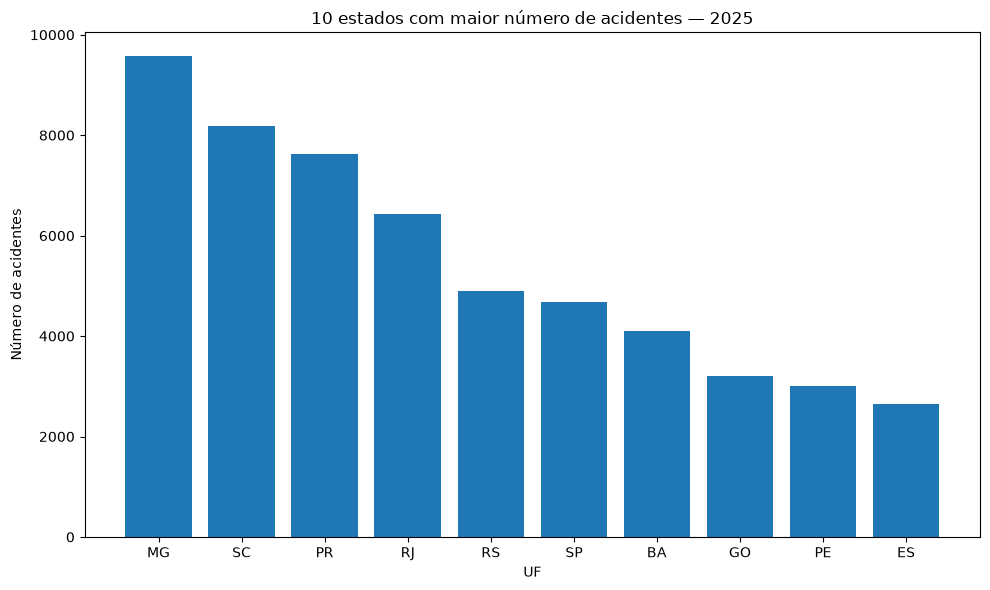

In [195]:
top10_uf = acidentes_uf.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top10_uf["uf"],
    top10_uf["acidentes"]
)

plt.title("10 estados com maior número de acidentes — 2025")
plt.xlabel("UF")
plt.ylabel("Número de acidentes")

plt.tight_layout()
plt.show()

Minas Gerais lidera a quantidade de acidentes registrados nas rodovias federais em 2025, com 9.570 ocorrências, correspondendo a aproximadamente 13,2% do total da base. Na sequência aparecem Santa Catarina, com 8.186 acidentes, e Paraná, com 7.630. Os três estados concentram juntos 25.386 acidentes, aproximadamente 35,0% de todas as ocorrências registradas.

### 4.2 Quais são os tipos de acidentes mais frequentes nas rodovias federais brasileiras?

In [229]:
acidentes_tipo = (
    df.groupby("tipo_acidente")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)

acidentes_tipo["perc_tipo"] = (acidentes_tipo["acidentes"] / acidentes_tipo["acidentes"].sum() * 100).round(2)

acidentes_tipo.head(10)

,tipo_acidente,acidentes,mortos,feridos,perc_tipo
8,Colisão traseira,14360,683,16376,19.80
14,Saída de leito carroçável,10209,700,11638,14.08
7,Colisão transversal,9306,481,12015,12.83
5,Colisão lateral mesmo sentido,7885,228,8839,10.87
16,Tombamento,6351,293,7241,8.76
3,Colisão com objeto,5109,323,4952,7.04
4,Colisão frontal,4739,1863,7596,6.53
13,Queda de ocupante de veículo,3450,89,4038,4.76
1,Atropelamento de Pedestre,3057,919,2846,4.21
6,Colisão lateral sentido oposto,2152,255,2824,2.97


In [226]:
top_3 = acidentes_tipo.head(3)
print(f"Total Top 3 tipos de acidentes: {top_3["acidentes"].sum().round(2)} ({top_3["perc_tipo"].sum().round(2)}%)")

Total Top 3 tipos de acidentes: 33875 (46.71%)


#### Gráfico — Tipos mais frequentes

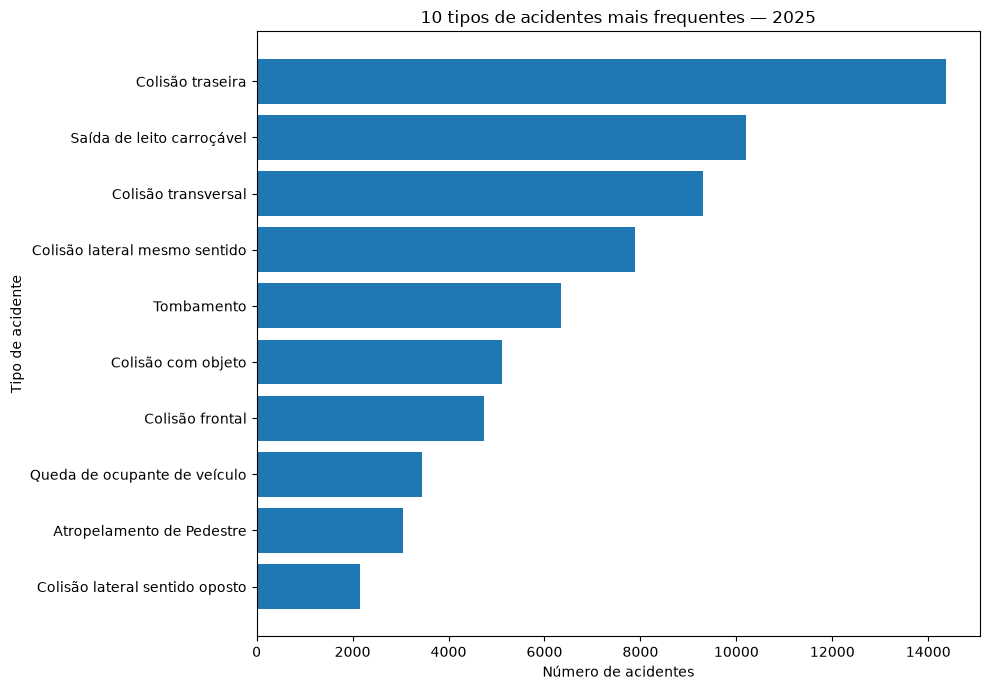

In [197]:
top10_tipos = acidentes_tipo.head(10).sort_values(
    "acidentes"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top10_tipos["tipo_acidente"],
    top10_tipos["acidentes"]
)

plt.title("10 tipos de acidentes mais frequentes — 2025")
plt.xlabel("Número de acidentes")
plt.ylabel("Tipo de acidente")

plt.tight_layout()
plt.show()

A colisão traseira é o tipo de acidente mais frequente, com 14.360 registros, seguida por saída de leito carroçável (10.209) e colisão transversal (9.306). Esses três tipos somam 33.875 ocorrências, aproximadamente 46,7% de todos os acidentes registrados

### 4.3 Quais tipos de acidentes apresentam maior gravidade, considerando o número de mortos e feridos?

In [ ]:
gravidade_tipo = (
    df.groupby("tipo_acidente")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum"),
          feridos_graves=("feridos_graves", "sum"),
          feridos_leves=("feridos_leves", "sum")
      )
      .reset_index()
)

gravidade_tipo["mortos_por_acidente"] = (
    gravidade_tipo["mortos"] /
    gravidade_tipo["acidentes"]
)

gravidade_tipo["feridos_por_acidente"] = (
    gravidade_tipo["feridos"] /
    gravidade_tipo["acidentes"]
)

gravidade_tipo["vitimas_por_acidente"] = (
    gravidade_tipo["mortos"] +
    gravidade_tipo["feridos"]
) / gravidade_tipo["acidentes"]


#Vamos utilizar a função Numpy np.divide() para fazer o cálculo, evitando problemas de divisão por zero
gravidade_tipo["mortos_por_100_acidentes"] = np.divide(
    gravidade_tipo["mortos"] * 100,
    gravidade_tipo["acidentes"],
    out=np.zeros(len(gravidade_tipo), dtype=float),
    where=gravidade_tipo["acidentes"] != 0
)

# Ordenar pelos tipos com maior número de mortos por acidente
tabela_gravidade = (
    gravidade_tipo
    .sort_values("mortos_por_acidente", ascending=False)
    .head(5)
)

# Selecionar e renomear as colunas
tabela_gravidade = tabela_gravidade[
    ["tipo_acidente", "acidentes", "mortos", "mortos_por_acidente"]
]

tabela_gravidade.columns = [
    "Tipo",
    "Acidentes",
    "Mortos",
    "Mortos/acidente"
]

# Imprimir a tabela
print(tabela_gravidade.to_string(index=False))


                          Tipo  Acidentes  Mortos  Mortos/acidente
               Colisão frontal       4739    1863         0.393121
     Atropelamento de Pedestre       3057     919         0.300622
Colisão lateral sentido oposto       2152     255         0.118494
              Eventos atípicos        287      24         0.083624
     Saída de leito carroçável      10209     700         0.068567


#### Gráfico — Tipos de acidente com maior gravidade

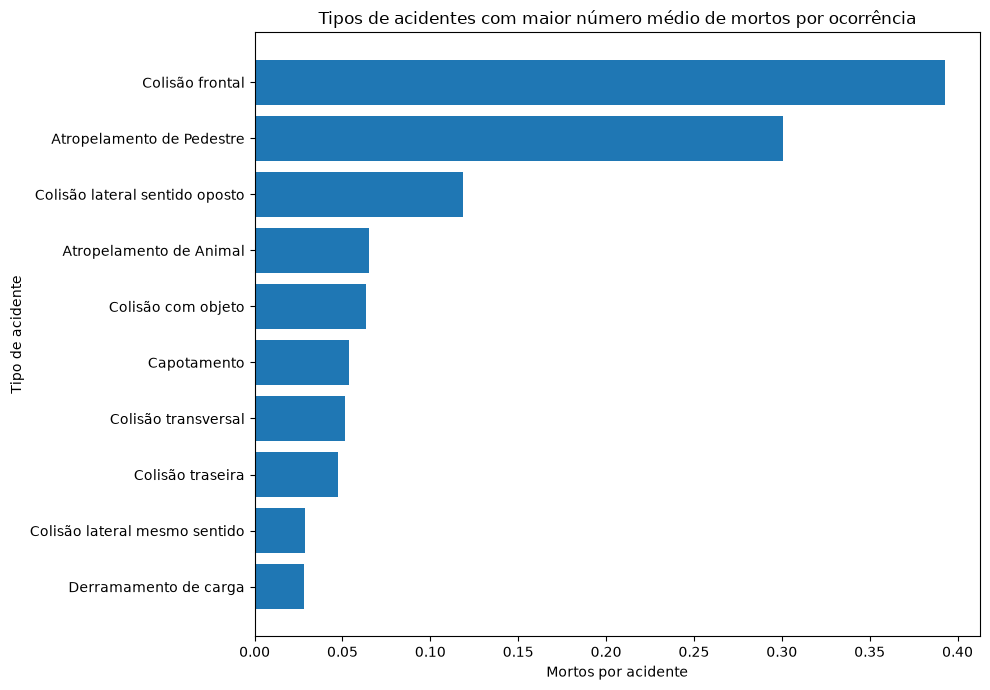

In [199]:
top_graves = gravidade_tipo.head(10).sort_values(
    "mortos_por_acidente"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_graves["tipo_acidente"],
    top_graves["mortos_por_acidente"]
)

plt.title(
    "Tipos de acidentes com maior número médio de mortos por ocorrência"
)

plt.xlabel("Mortos por acidente")
plt.ylabel("Tipo de acidente")

plt.tight_layout()
plt.show()

**Gravidade absoluta:** quantidade total de mortes

**Gravidade relativa:** Quantidade média de vítimas por acidente 

A colisão frontal apresenta a maior gravidade relativa, com aproximadamente 0,393 morto por acidente. O atropelamento de pedestre aparece em segundo lugar, com 0,301 morto por ocorrência. 

Em termos absolutos, a colisão frontal também se destaca: foram 1.863 mortes em 2025, muito acima dos demais tipos. 

*Portanto, colisão frontal além de liderar em mortes, também apresenta a maior média de vítimas entre os principais tipos.*

### 4.4 Quais condições meteorológicas estão associadas à maior ocorrência?

In [228]:
acidentes_clima = (
    df.groupby("condicao_metereologica")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)

acidentes_clima["perc_acidentes"] = (acidentes_clima["acidentes"] / acidentes_clima["acidentes"].sum() * 100).round(2)


acidentes_clima

,condicao_metereologica,acidentes,mortos,feridos,perc_acidentes
1,Céu Claro,46375,3948,52641,63.94
6,Nublado,11435,955,13176,15.77
0,Chuva,6438,480,8192,8.88
7,Sol,4201,286,4988,5.79
2,Garoa/Chuvisco,2422,175,2793,3.34
3,Ignorado,1000,115,1025,1.38
5,Nevoeiro/Neblina,553,74,617,0.76
8,Vento,104,10,117,0.14
4,Neve,1,0,1,0.00


#### Gráfico — Condições meteorológicas

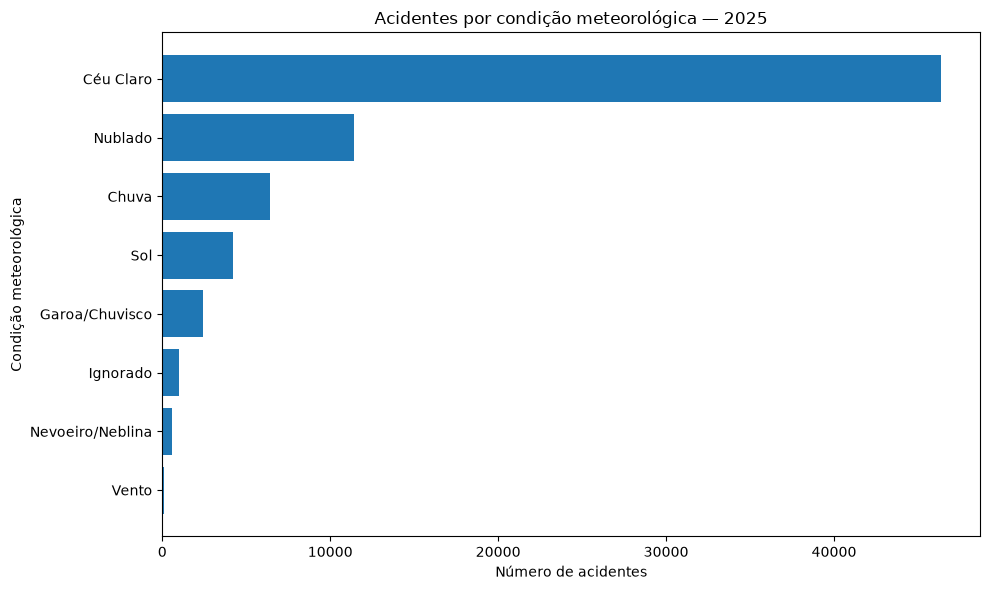

In [201]:
clima_plot = acidentes_clima.head(8).sort_values(
    "acidentes"
)

plt.figure(figsize=(10, 6))

plt.barh(
    clima_plot["condicao_metereologica"],
    clima_plot["acidentes"]
)

plt.title("Acidentes por condição meteorológica — 2025")
plt.xlabel("Número de acidentes")
plt.ylabel("Condição meteorológica")

plt.tight_layout()
plt.show()

A maior parte dos acidentes ocorreu sob céu claro: 46.375 ocorrências, equivalentes a 63,9% da base. Em seguida aparecem condições nubladas (11.435) e chuva (6.438). Entretanto, esse resultado não permite concluir que céu claro aumenta o risco de acidentes. Para medir associação com risco seria necessário controlar pela exposição, como quantidade de veículos circulando em cada condição meteorológica.

### 4.5 — Em quais meses ocorre maior concentração de acidadentes?

In [202]:
df["mes"] = df["data_inversa"].dt.month

acidentes_mes = (
    df.groupby("mes")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum")
      )
      .reset_index()
)

acidentes_mes

,mes,acidentes,mortos,feridos
0,1,5528,418,6915
1,2,5287,412,5974
2,3,5960,462,6784
3,4,5786,495,6678
4,5,6096,574,6834
5,6,6122,528,6920
6,7,6238,536,7129
7,8,6246,554,7006
8,9,6017,500,6876
9,10,6252,494,7231


Dezembro apresenta a maior quantidade de acidentes: 6.788.
Fevereiro apresenta a menor: 5.287

#### Gráfico - Acidentes por mês

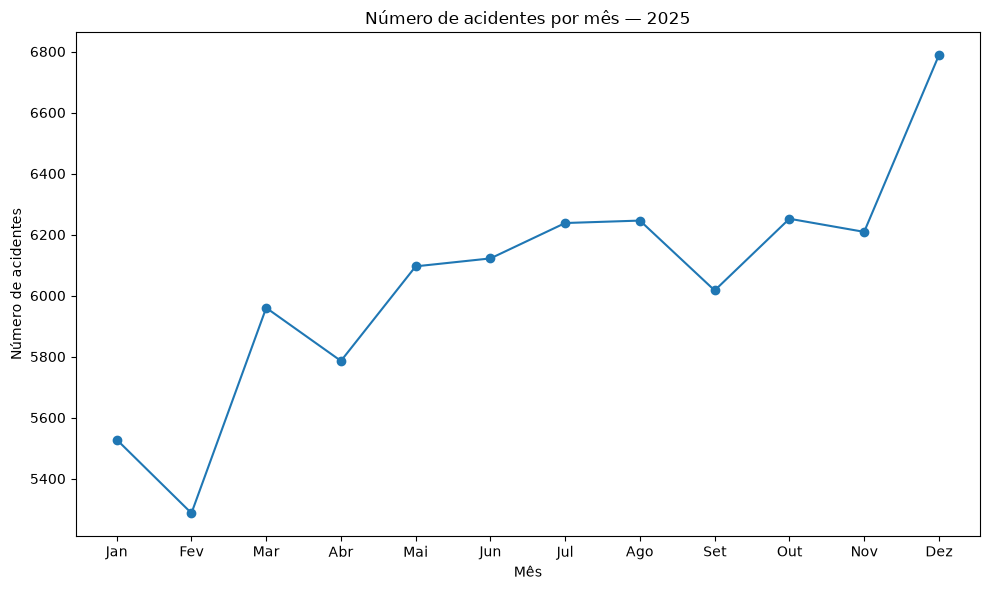

In [203]:
meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

plt.figure(figsize=(10, 6))

plt.plot(
    meses,
    acidentes_mes["acidentes"],
    marker="o"
)

plt.title("Número de acidentes por mês — 2025")
plt.xlabel("Mês")
plt.ylabel("Número de acidentes")

plt.tight_layout()
plt.show()

A quantidade de acidentes apresenta tendência de crescimento ao longo do segundo semestre, atingindo o maior valor em dezembro, com 6.788 ocorrências. O menor volume foi registrado em fevereiro, com 5.287. A diferença entre os dois meses é de 1.501 acidentes, aproximadamente 28,4% a mais em dezembro.

#### Pivot_table — mês × período

In [204]:
tabela_mes_periodo = pd.pivot_table(
    df,
    index="mes",
    columns="fase_dia",
    values="id",
    aggfunc="count",
    fill_value=0
)

tabela_mes_periodo

fase_dia,Amanhecer,Anoitecer,Plena Noite,Pleno dia
mes,,,,
1,241,291,1581,3415
2,246,271,1675,3095
3,283,305,1990,3382
4,262,297,2093,3134
5,317,381,2203,3195
6,344,370,2311,3097
7,347,367,2243,3281
8,307,377,2286,3276
9,250,322,2042,3403


# EXTRAS

In [205]:
acidentes_periodo = (
    df.groupby("fase_dia")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)

acidentes_periodo

,fase_dia,acidentes,mortos,feridos
3,Pleno dia,40375,2391,48052
2,Plena Noite,24781,2892,27179
1,Anoitecer,3926,288,4558
0,Amanhecer,3447,472,3761


Embora o Pleno dia tenha muito mais acidentes, a Plena Noite teve mais mortes:

Pleno dia → 2.391 mortes
Plena Noite → 2.892 mortes

Isso sugere que frequência e gravidade não são necessariamente a mesma coisa.

In [206]:
tabela_dia_semana = pd.pivot_table(
    df,
    index="dia_semana",
    columns="fase_dia",
    values="id",
    aggfunc="count",
    fill_value=0
)

tabela_dia_semana

fase_dia,Amanhecer,Anoitecer,Plena Noite,Pleno dia
dia_semana,,,,
domingo,631,633,4832,5374
quarta-feira,389,573,2912,5682
quinta-feira,422,501,2973,5509
segunda-feira,518,573,2942,6252
sexta-feira,493,634,3829,6241
sábado,602,467,4710,5775
terça-feira,392,545,2583,5542


Considerando que os acidentes com mais vitimas fatais(mortes) ocorrem em "Plena Noite", com maior incidência nos dias da semana Domingo, Sábado e Sexta Feira.

# ETAPA 5: Conclusões